# Feature Removal
This playground is created with the only purpose to check out if the removal of pretty unused features upgrades the classifier, if it's neutral or makes it worse. We start with the same dataset as before and the objective of the whole experiment is to process the data with the best classifier we obtained before (random forest) by implementing a 15 folds stratified cross validation. Instead of simply splitting the dataset in 15 parts, which serve to the purpose of changing the training/testing sets fifteen times, for each fold we consider only the most important features for the trees, incrementing the number of the feature (sorted by importance in ascending order) two by two for each fold, until we return to the point of start with the last fold containing and evaluating all the thirty features.

In [1]:
import pandas as pd
import numpy as np
import re
import socket
import whois
import requests
import joblib
import warnings
import math
import hashlib
import logging
import base64

from datetime import datetime
from urllib.parse import urlparse
from scipy.io import arff
from scipy.stats import chi2_contingency
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.pipeline import make_pipeline
from sklearn.metrics import make_scorer, f1_score, accuracy_score, precision_score, recall_score
from sklearn.metrics import classification_report
from collections import defaultdict


from pandas.plotting import scatter_matrix
from matplotlib import pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    cross_val_predict,
    cross_val_score,
    StratifiedKFold
)
from sklearn.metrics import roc_curve, auc
from sklearn.feature_selection import mutual_info_classif
from sklearn.exceptions import NotFittedError
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn import svm
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [2]:
train = pd.read_csv('./TrainingDataset.csv')
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11055 entries, 0 to 11054
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   having_IP_Address            11055 non-null  int64
 1   URL_Length                   11055 non-null  int64
 2   Shortining_Service           11055 non-null  int64
 3   having_At_Symbol             11055 non-null  int64
 4   double_slash_redirecting     11055 non-null  int64
 5   Prefix_Suffix                11055 non-null  int64
 6   having_Sub_Domain            11055 non-null  int64
 7   SSLfinal_State               11055 non-null  int64
 8   Domain_registeration_length  11055 non-null  int64
 9   Favicon                      11055 non-null  int64
 10  port                         11055 non-null  int64
 11  HTTPS_token                  11055 non-null  int64
 12  Request_URL                  11055 non-null  int64
 13  URL_of_Anchor                11055 non-null  i

# Preprocessing

In [3]:
# Features and target
X = train.drop(columns=["Result"])
y = train["Result"]

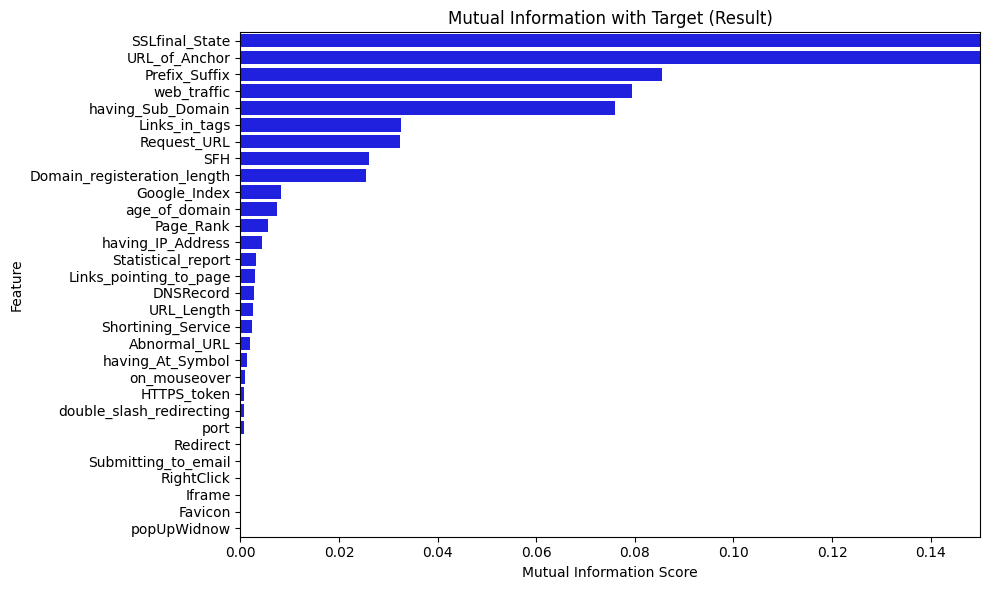

In [4]:
# Mutual Information Heatmap (feature-to-target importance)
'''
Measures information gain between features and the target.
Non-parametric and works very well for categorical datasets.
Great to understand which features are informative for classification.
Entropy estimation from k-nearest neighbors distances.
'''

# Compute mutual information
mi_scores = mutual_info_classif(X, y, discrete_features=True)
mi_series = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)

# Plot
plt.figure(figsize=(10, 6))
plt.xlim(0,0.15)
sns.barplot(x=mi_series.values, y=mi_series.index, color="blue")
plt.title("Mutual Information with Target (Result)")
plt.xlabel("Mutual Information Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# Processing


Fold-by-Fold Metrics (Increasing Features)
Fold  1 | Top_k:  2 features | Acc: 0.9037 | F1-macro: 0.9018
Fold  2 | Top_k:  4 features | Acc: 0.9281 | F1-macro: 0.9268
Fold  3 | Top_k:  6 features | Acc: 0.9322 | F1-macro: 0.9309
Fold  4 | Top_k:  8 features | Acc: 0.9457 | F1-macro: 0.9451
Fold  5 | Top_k: 10 features | Acc: 0.9498 | F1-macro: 0.9490
Fold  6 | Top_k: 12 features | Acc: 0.9498 | F1-macro: 0.9491
Fold  7 | Top_k: 14 features | Acc: 0.9620 | F1-macro: 0.9614
Fold  8 | Top_k: 16 features | Acc: 0.9729 | F1-macro: 0.9725
Fold  9 | Top_k: 18 features | Acc: 0.9607 | F1-macro: 0.9600
Fold 10 | Top_k: 20 features | Acc: 0.9688 | F1-macro: 0.9683
Fold 11 | Top_k: 22 features | Acc: 0.9742 | F1-macro: 0.9738
Fold 12 | Top_k: 24 features | Acc: 0.9593 | F1-macro: 0.9585
Fold 13 | Top_k: 26 features | Acc: 0.9729 | F1-macro: 0.9724
Fold 14 | Top_k: 28 features | Acc: 0.9729 | F1-macro: 0.9725
Fold 15 | Top_k: 30 features | Acc: 0.9729 | F1-macro: 0.9724

=== Fold Performance Summ

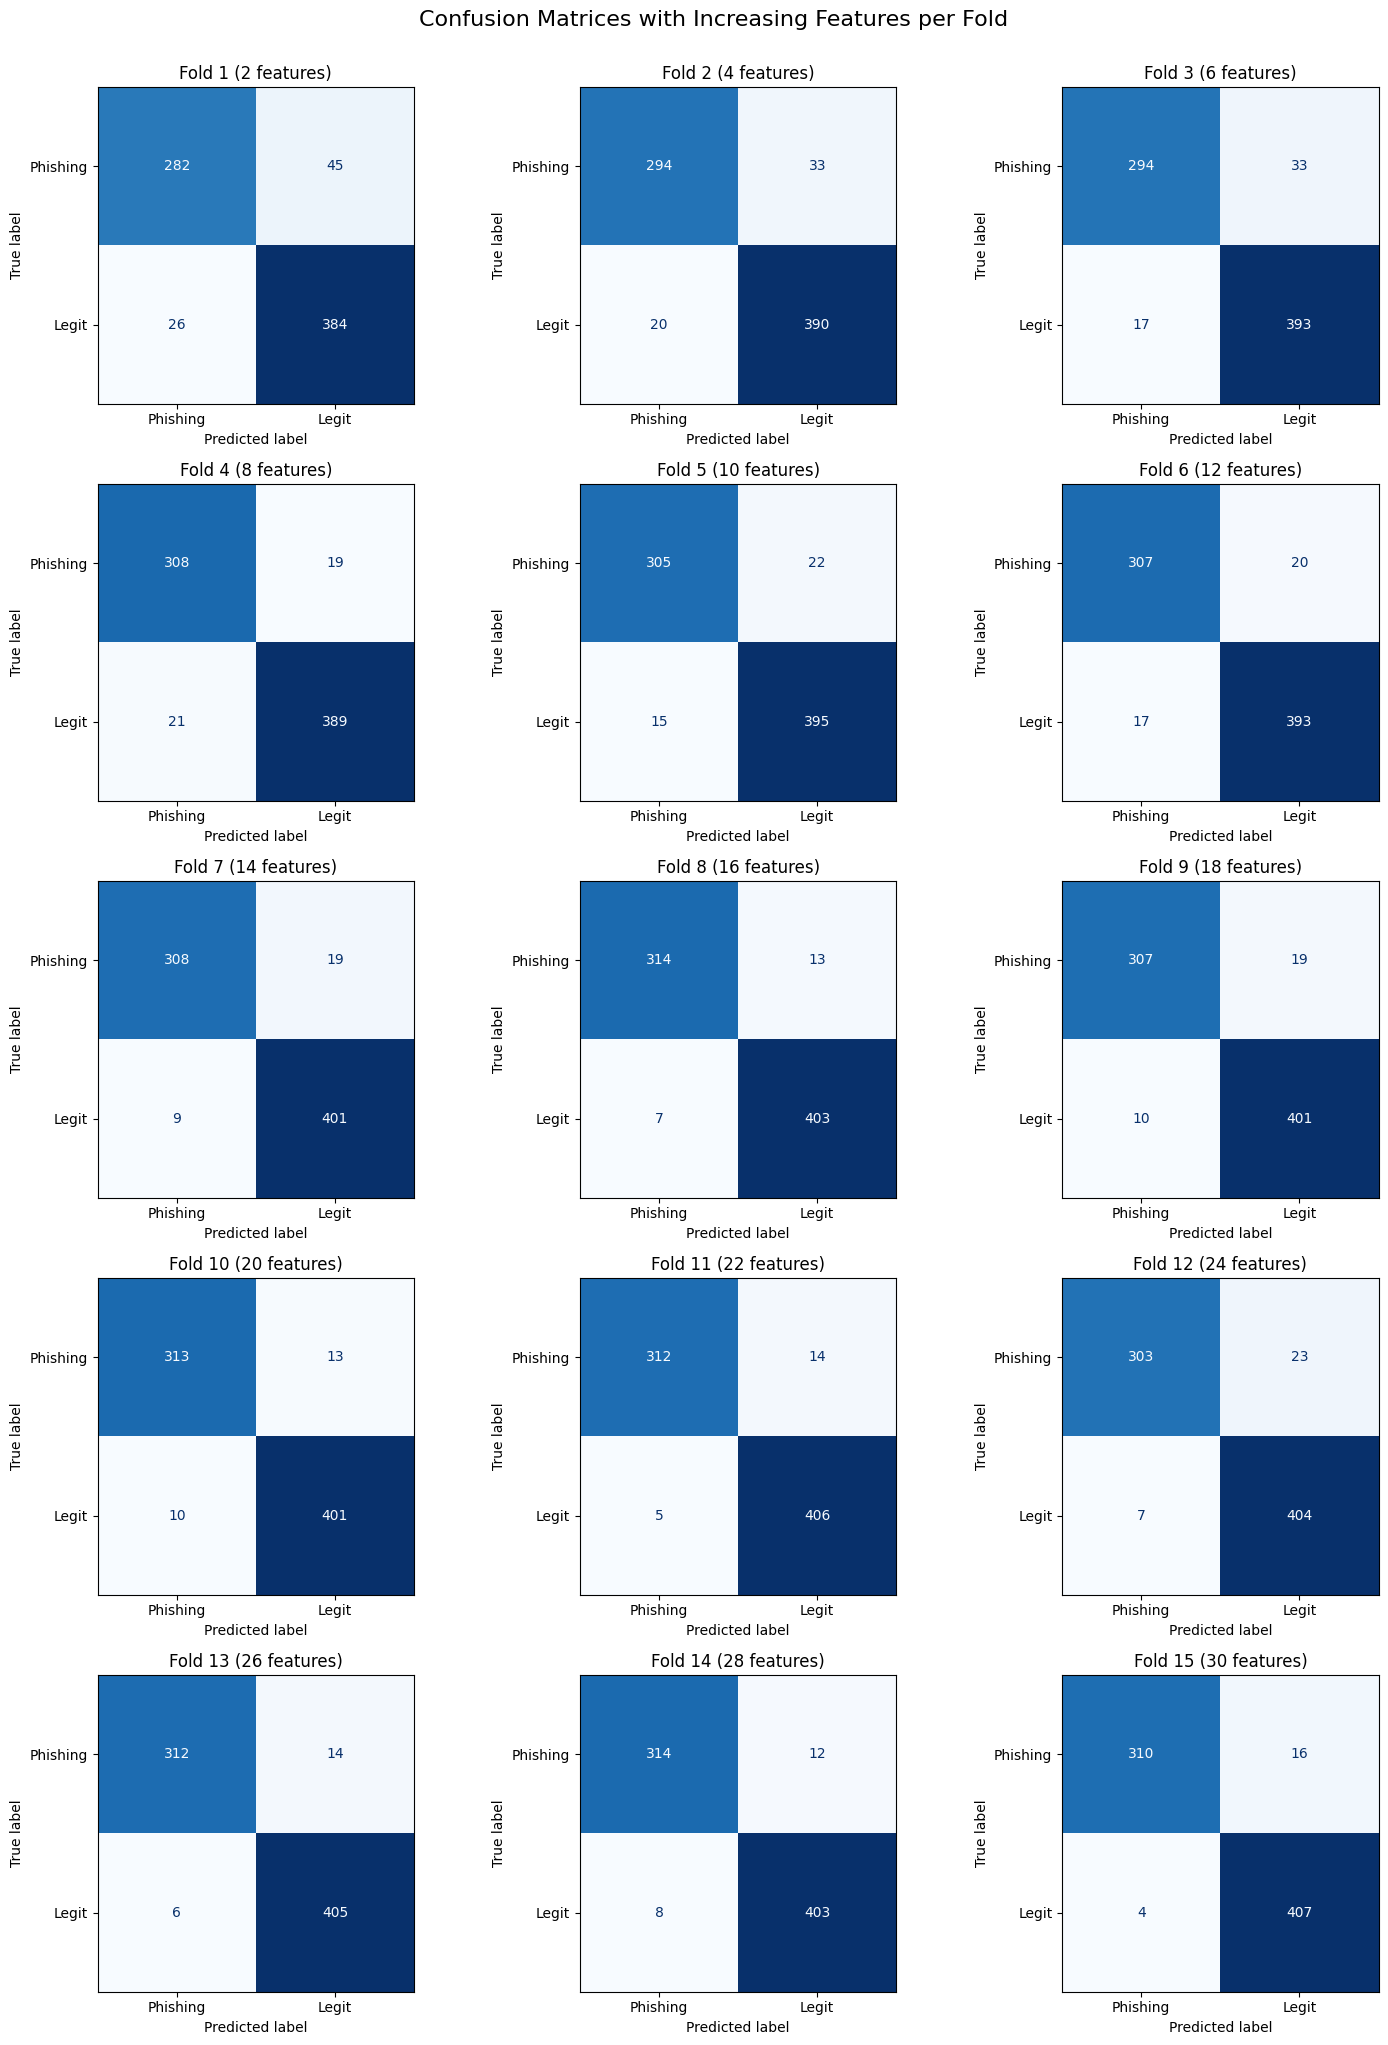

In [5]:
# Calcola l'importanza delle feature
mi_series = pd.Series(mutual_info_classif(X, y, discrete_features=True), index=X.columns).sort_values(ascending=False)

# Inizializza modello e cross-validation
skf = StratifiedKFold(n_splits=15, shuffle=True, random_state=42)
modelRF = RandomForestClassifier(random_state=42)

# Liste metriche
accuracy_rf_list = []
f1_rf_list = []
fold_summaries = []  # Per stampa riassuntiva
class_metrics = defaultdict(list)

# Setup per il grafico
n_folds = skf.get_n_splits()
cols = 3
rows = math.ceil(n_folds / cols)
fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 4))
axes = axes.flatten()

print("\nFold-by-Fold Metrics (Increasing Features)")
print("==========================================")
for i, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    top_k = (i + 1) * 2  # Incrementa di 2 feature a ogni fold
    feature_top_k = mi_series.head(top_k).index

    # Estrazione dei dati
    X_train_fold = X.iloc[train_idx][feature_top_k]
    X_test_fold = X.iloc[val_idx][feature_top_k]
    y_train_fold = y.iloc[train_idx]
    y_test_fold = y.iloc[val_idx]

    # Fit e predizione
    modelRF.fit(X_train_fold, y_train_fold)
    y_pred = modelRF.predict(X_test_fold)

    # Metriche generali
    acc = accuracy_score(y_test_fold, y_pred)
    f1 = f1_score(y_test_fold, y_pred, average='macro')

    accuracy_rf_list.append(acc)
    f1_rf_list.append(f1)
    fold_summaries.append((i+1, top_k, acc, f1))  # Salva per riepilogo

    print(f"Fold {i+1:2d} | Top_k: {top_k:2d} features | Acc: {acc:.4f} | F1-macro: {f1:.4f}")

    # Metriche per classe
    report = classification_report(y_test_fold, y_pred, output_dict=True)
    for label in ['-1', '1']:
        for metric in ['precision', 'recall', 'f1-score']:
            class_metrics[(label, metric)].append(report[label][metric])

    # Confusion matrix
    cm = confusion_matrix(y_test_fold, y_pred, labels=[-1, 1])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Phishing', 'Legit'])
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(f"Fold {i+1} ({top_k} features)")

# Riepilogo dei risultati ordinati per F1 decrescente
print("\n=== Fold Performance Summary (sorted by F1) ===")
sorted_summary = sorted(fold_summaries, key=lambda x: x[3], reverse=True)
for fold, top_k, acc, f1 in sorted_summary:
    print(f"Fold {fold:2d} | Features: {top_k:2d} | Acc: {acc:.4f} | F1-macro: {f1:.4f}")

print('\n')

# Rimuovi subplot vuoti
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle("Confusion Matrices with Increasing Features per Fold", fontsize=16, y=1.02)
plt.show()


# Conclusion
As expected the model decreases sensibly its accuracy with too few attributes considered to train the model, reaching an accuracy and an f1 statistics a bit greater than 0.90, these values grow sensibly for the first ten folds, corresponding to consider only 20/30 features, reaching an accuracy and a f1 score almost of the 0.97. 

When we check from 22 features considered to the whole dataset we expect to notice not a substantial change, but a less and less growing of the performance; in fact, by looking a the result we notice that the most performant (with an accuracy and f1 score greater than 0.97) folds are the ones with a number of features between the 22 and the 30, with an outlier having only 16 features, this exception is purely randomic by looking a the results obtained by changing the randomic seed for the stratified cv function or for the random forest model function.

It's pretty expectable to obtain results like these by taking a prior look at the mutual information plot, which displays the most important attribute for the splitting of the trees. The first ten (considering the less important) are almost never useful, presenting a probability corresponding almost to zero. So, for performance reasons, the model can be trained and used with less attributes (decreasing the accuracy of a bit however) than the whole initial set, but keeping a decent number of attributes though, minimum 22 (to guarantee an almost optimal accuracy).